In [2]:
import torch
torch.cuda.is_available()

False

# SR-VAE for BioSR fluorescence microscopy (2× super-resolution)

Base paper: Liu, Siu, Chan, *Photo-Realistic Image Super-Resolution via Variational Autoencoders*, IEEE TCSVT 2021.
Equation numbers in code comments (Eq. N) refer to that paper.

**Pipeline in one line:** widefield patch (LR, X) + SIM patch (HR, Y) → encoder → latent code z → decoder(z, X) → SR image Y'.

**Notation**
- X: LR widefield image, Y: HR SIM image, z: latent vector, Y': super-resolved output
- Q(z|X,Y) = N(μ, σ²I): encoder (posterior), P(z) = N(0, I): prior
- G(X): conditional sampling generator, replaces ε ~ N(0, I)

**Loss (Eq. 12–13)**

$$L = \underbrace{\|Y-Y'\|_1 + \lambda\,\|\phi_{54}(Y)-\phi_{54}(Y')\|_1}_{L_{SR}} + \beta\, D_{KL}\big(Q(z|X,Y)\,\|\,\mathcal N(0,I)\big)$$

**Training:** $z = \mu + \sigma\cdot G(X)$ \
**Testing:** $z = G(X)$ (encoder dropped)

**Changes for BioSR:** grayscale (1 channel), scale 2 (one UBP block), VGG loss off by default, tiled inference for full images, KL averaged per latent dim with weight β.

## 0. Install (run once)

In [1]:
# !pip install torch torchvision numpy scikit-image mrcfile tifffile matplotlib

## 1. Imports

In [2]:
import glob, math, os, random, time
from types import SimpleNamespace

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

## 2. Data (BioSR paired widefield / SIM)

Expected layout: `<data_root>/<structure>/{training_wf, training_gt, validate_wf, validate_gt}/`.
Each widefield image is paired with the SIM image of the same file name (falls back to sorted order).
Both are percentile-normalised to [0, 1]. GT must be exactly `scale` × the widefield size.

In [ ]:
def read_stack(path):
    """Read .mrc / .tif / .npy into a float32 numpy array."""
    ext = os.path.splitext(path)[1].lower()
    if ext in (".mrc", ".rec", ".st"):
        import mrcfile
        with mrcfile.open(path, permissive=True) as m:
            return np.array(m.data, dtype=np.float32)
    if ext in (".tif", ".tiff"):
        import tifffile
        return tifffile.imread(path).astype(np.float32)
    if ext == ".npy":
        return np.load(path).astype(np.float32)
    if ext in (".png", ".jpg", ".jpeg", ".bmp"):
        from skimage import io
        a = io.imread(path).astype(np.float32)
        return a[..., :3].mean(axis=-1) if a.ndim == 3 else a      # RGB -> gray
    raise ValueError(f"Unsupported file type: {path}")

## normalize wala part
def percentile_norm(img, lo=0.03, hi=99.7):
    """Robust intensity normalisation to [0,1]:  x' = clip((x - p_lo) / (p_hi - p_lo), 0, 1)."""
    a, b = np.percentile(img, [lo, hi])
    return np.clip((img - a) / (b - a + 1e-8), 0.0, 1.0).astype(np.float32)


IMG_EXTS = (".tif", ".tiff", ".png", ".mrc", ".npy")


def list_images(folder):
    return sorted(f for f in glob.glob(os.path.join(folder, "*")) if f.lower().endswith(IMG_EXTS))


def load_folder_pairs(wf_dir, gt_dir, scale):
    """
    Pairs every widefield image in wf_dir with its SIM image in gt_dir.
    Pairing rule: same file name (ignoring extension); if no names match, fall back to sorted order.
    LR = widefield (if a stack, mean over frames: X = (1/T) sum_t raw_t), HR = SIM ground truth.
    Returns a list of (lr, hr) 2D float arrays normalised to [0, 1], with hr.shape == scale * lr.shape.
    """
    wf, gt = list_images(wf_dir), list_images(gt_dir)
    if not wf or not gt:
        raise RuntimeError(f"No images found in {wf_dir} or {gt_dir}")
    stem = lambda p: os.path.splitext(os.path.basename(p))[0]
    gt_by_stem = {stem(p): p for p in gt}
    matched = [(p, gt_by_stem[stem(p)]) for p in wf if stem(p) in gt_by_stem]
    if not matched:
        print(f"[warn] no matching file names in {wf_dir} / {gt_dir}; pairing by sorted order")
        matched = list(zip(wf, gt))
    out = []
    for lp, hp in matched:
        lr = read_stack(lp)
        while lr.ndim > 2:
            lr = lr.mean(axis=0)
        hr = read_stack(hp)
        while hr.ndim > 2:
            hr = hr[0]
        H, W = lr.shape
        hr = hr[: H * scale, : W * scale]
        if hr.shape != (H * scale, W * scale):
            print(f"[skip] {os.path.basename(lp)}: HR {hr.shape} is not {scale} x LR {lr.shape}")
            continue
        out.append((percentile_norm(lr), percentile_norm(hr)))
    if not out:
        raise RuntimeError("No valid pairs. Check scale and that GT is exactly scale x the widefield size.")
    print(f"{wf_dir}: {len(out)} pairs")
    return out


class PatchDataset(Dataset):
    """Random aligned LR/HR crops with flips and 90-degree rotations (paper: flip + rotation)."""

    def __init__(self, pairs, lr_patch, scale, samples_per_epoch):
        ##imp namings shorts
        self.pairs, self.p, self.s, self.n = pairs, lr_patch, scale, samples_per_epoch

    def __len__(self):
        return self.n

    def __getitem__(self, _):
        lr, hr = random.choice(self.pairs)
        H, W = lr.shape
        y, x = random.randint(0, H - self.p), random.randint(0, W - self.p)
        lp = lr[y:y + self.p, x:x + self.p]
        hp = hr[y * self.s:(y + self.p) * self.s, x * self.s:(x + self.p) * self.s]
        k = random.randint(0, 3)
        lp, hp = np.rot90(lp, k), np.rot90(hp, k)
        if random.random() < 0.5:
            lp, hp = lp[:, ::-1], hp[:, ::-1]
        return (torch.from_numpy(np.ascontiguousarray(lp))[None],
                torch.from_numpy(np.ascontiguousarray(hp))[None])

## 3. Model

### 3.1 Enhanced UBP block (back-projection, 2× per block)

In [4]:
class EnhancedUBP(nn.Module):
    """
    Enhanced Up-sampling Back-Projection block (Fig. 4b), 2x per block.
    Back-projection idea (DBPN): up-project, down-project back, and use the LR-space
    error to correct the HR estimate.
        h0 = PReLU( Deconv(x) )                 # HR estimate            (H -> 2H)
        l0 = Conv(h0)                           # project back to LR     (2H -> H)
        r  = l0 - x                             # LR-space residual
        h1 = Deconv( Conv1x1_a(r) )             # residual mapped to HR (1x1 conv = weighted shortcut)
        y  = h0 + Conv1x1_b(h1)                 # weighted addition = residual update
    Paper: 6x6 kernels, stride 2 (pad 2 -> exact 2x), 1x1 convs for weighting, and one
    activation after the first deconv only (the second one was removed as redundant).
    (The exact wiring of the two 1x1 convs is our reading of Fig. 4b.)
    """

    def __init__(self, nf):
        super().__init__()
        self.up1 = nn.ConvTranspose2d(nf, nf, 6, 2, 2)
        self.act = nn.PReLU(nf)
        self.down = nn.Conv2d(nf, nf, 6, 2, 2)
        self.res_1x1 = nn.Conv2d(nf, nf, 1)
        self.up2 = nn.ConvTranspose2d(nf, nf, 6, 2, 2)
        self.out_1x1 = nn.Conv2d(nf, nf, 1)

    def forward(self, x):
        h0 = self.act(self.up1(x))
        r = self.down(h0) - x
        h1 = self.up2(self.res_1x1(r))
        return h0 + self.out_1x1(h1)

### 3.2 LR-HR Encoder: Q(z | X, Y) → μ, log σ²

$\sigma = \exp(0.5\cdot\text{logvar})$

In [5]:
class LRHREncoder(nn.Module):
    """
    Q(z | X, Y): outputs mu(X,Y) and log sigma^2(X,Y) (Fig. 2, "LR-HR Encoder").
    Two conv branches (one for Y, one for the bicubic-upsampled X) are fused with an
    element-wise sum, then FC layers give the k-dim mean and log-variance.
    Predicting log(sigma^2) instead of sigma^2 keeps the variance positive:
        sigma = exp(0.5 * logvar)
    """

    def __init__(self, patch_hr=128, z_dim=256, fc_hidden=2048, chs=(32, 64, 128, 256, 256)):
        super().__init__()
        assert patch_hr % 32 == 0, "HR patch must be divisible by 32 (5 stride-2 convs)"

        def branch():
            layers, c = [], 1
            for co in chs:
                layers += [nn.Conv2d(c, co, 3, 2, 1), nn.ReLU(inplace=True)]
                c = co
            return nn.Sequential(*layers)

        self.hr_branch, self.lr_branch = branch(), branch()
        flat = chs[-1] * (patch_hr // 32) ** 2
        self.fc = nn.Sequential(nn.Flatten(), nn.Linear(flat, fc_hidden), nn.ReLU(inplace=True),
                                nn.Linear(fc_hidden, fc_hidden), nn.ReLU(inplace=True))
        self.mu = nn.Linear(fc_hidden, z_dim)
        self.logvar = nn.Linear(fc_hidden, z_dim)

    def forward(self, hr, lr_up):
        f = self.fc(self.hr_branch(hr) + self.lr_branch(lr_up))     # (+) fusion, Fig. 2
        return self.mu(f), self.logvar(f).clamp(-10.0, 10.0)

### 3.3 Conditional sampling generator G(X)

A learned, LR-conditioned, normalised vector used in place of ε ~ N(0, I).

In [6]:
class ConditionalSamplingGenerator(nn.Module):
    """
    G(X): conditional sampling generator (Sec. III-C, Fig. 5).
    Instead of drawing eps ~ N(0, I) in the reparameterisation trick, the noise is a learned,
    LR-conditioned vector that is normalised to zero mean / unit variance:
        g = Normalize( FC( ReLU( FC( Normalize(X) ) ) ) )
    Because g has zero mean and unit variance, it is a valid stand-in for eps, but it now
    carries information about X (the "low-frequency components" argument of the paper).
    """

    def __init__(self, z_dim=256, in_size=32, hidden=1024):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(in_size)      # makes G independent of the LR size
        self.fc1 = nn.Linear(in_size * in_size, hidden)
        self.fc2 = nn.Linear(hidden, z_dim)

    @staticmethod
    def _norm(v, eps=1e-6):
        return (v - v.mean(1, keepdim=True)) / (v.std(1, keepdim=True) + eps)

    def forward(self, lr):
        x = self._norm(self.pool(lr).flatten(1))       # centre LR to mean 0, var 1
        return self._norm(self.fc2(F.relu(self.fc1(x))))

### 3.4 SR decoder: latent path + LR path → UBP blocks → + bicubic(X)

In [7]:
class SRDecoder(nn.Module):
    """
    P(Y | z, X): SR decoder (Fig. 2 / Fig. 8).
        latent path : z -> FC -> FC -> reshape -> resize to LR size -> conv
        LR path     : X -> conv stack (LR resolution)
        fuse        : element-wise addition ("Addition" block, keeps SR close to the LR image)
        upsample    : log2(scale) enhanced UBP blocks (gradual 2x steps)
        output      : Y' = Conv(features) + Bicubic(X)         (global residual, "X'" in Fig. 2)
    """

    def __init__(self, z_dim=256, nf=64, scale=2, fc_hidden=2048, lat_ch=16, lat_hw=16):
        super().__init__()
        assert scale in (2, 4, 8), "scale must be a power of two"
        self.scale, self.lat_ch, self.lat_hw = scale, lat_ch, lat_hw
        self.fc = nn.Sequential(nn.Linear(z_dim, fc_hidden), nn.PReLU(),
                                nn.Linear(fc_hidden, lat_ch * lat_hw * lat_hw), nn.PReLU())
        self.lat_conv = nn.Sequential(nn.Conv2d(lat_ch, nf, 3, 1, 1), nn.PReLU(nf))
        self.lr_branch = nn.Sequential(nn.Conv2d(1, nf // 2, 3, 1, 1), nn.PReLU(nf // 2),
                                       nn.Conv2d(nf // 2, nf, 3, 1, 1), nn.PReLU(nf),
                                       nn.Conv2d(nf, nf, 3, 1, 1), nn.PReLU(nf))
        self.ubps = nn.Sequential(*[EnhancedUBP(nf) for _ in range(int(math.log2(scale)))])
        self.tail = nn.Conv2d(nf, 1, 3, 1, 1)

    def forward(self, z, lr):
        f_lr = self.lr_branch(lr)
        lat = self.fc(z).view(z.size(0), self.lat_ch, self.lat_hw, self.lat_hw)
        lat = F.interpolate(lat, size=f_lr.shape[-2:], mode="bilinear", align_corners=False)
        x = f_lr + self.lat_conv(lat)
        x = self.tail(self.ubps(x))
        return x + F.interpolate(lr, scale_factor=self.scale, mode="bicubic", align_corners=False)

### 3.5 Full SR-VAE (latent space is the `z = mu + sigma * g` line)

Training: $z=\mu+\sigma\, G(X)$. Testing: $z=G(X)$.

In [8]:
class SRVAE(nn.Module):
    """
    Full SR-VAE.
    Training (needs Y):
        (mu, logvar) = Enc(Y, Bicubic(X))
        z  = mu + sigma * G(X),        sigma = exp(0.5 logvar)      # conditional reparam. trick
        Y' = Dec(z, X)
      (the standard trick is z = mu + sigma * eps, eps ~ N(0, I); Eq. 8-9, 10-11)
    Testing (Y not available, encoder is discarded, Fig. 8):
        z  = G(X)        # equals mu=0, sigma=1 (the prior) once KL -> 0
        Y' = Dec(z, X)
    """

    def __init__(self, scale=2, patch_lr=64, z_dim=256, nf=64, fc_hidden=2048):
        super().__init__()
        self.scale = scale
        self.enc = LRHREncoder(patch_lr * scale, z_dim, fc_hidden)
        self.gen = ConditionalSamplingGenerator(z_dim)
        self.dec = SRDecoder(z_dim, nf, scale, fc_hidden)

    def forward(self, lr, hr=None):
        g = self.gen(lr)
        if hr is None:
            return self.dec(g, lr), None, None
        lr_up = F.interpolate(lr, scale_factor=self.scale, mode="bicubic", align_corners=False)
        mu, logvar = self.enc(hr, lr_up)
        z = mu + torch.exp(0.5 * logvar) * g
        return self.dec(z, lr), mu, logvar

### 3.6 Optional VGG perceptual features φ₅₄ (avg-pool VGG19, off by default)

In [ ]:
# ============================================================================================
# REPLACEMENT for the code cell in "3.6 Optional VGG perceptual features" (cell 18, class VGGFeat).
# VGG19's FIRST conv layer is changed from 3 input channels to 1, so grayscale images go in directly.
# ============================================================================================
class VGGFeat(nn.Module):
    """
    phi_54: VGG19 features up to conv5_4 (frozen), MaxPool -> AvgPool as in the paper.

    First-layer change (3 -> 1 input channel):
        pretrained conv1 weight W has shape (64, 3, 3, 3): one 3x3 filter per colour channel.
        new weight      W_gray = W_R + W_G + W_B   -> shape (64, 1, 3, 3)
        conv(x, W_gray) = conv(x, W_R) + conv(x, W_G) + conv(x, W_B)
    i.e. the new layer reproduces what the pretrained layer would output for an image whose
    R, G, B channels are all equal to x (grayscale), while taking a single-channel input.
    Input normalisation uses the mean of the ImageNet channel means / stds:
        mean = (0.485 + 0.456 + 0.406) / 3 = 0.449,   std = (0.229 + 0.224 + 0.225) / 3 = 0.226
    """

    def __init__(self):
        super().__init__()
        import torchvision
        vgg = torchvision.models.vgg19(weights=torchvision.models.VGG19_Weights.IMAGENET1K_V1).features[:35]

        old = vgg[0]                                                   # Conv2d(3, 64, 3, padding=1)
        new = nn.Conv2d(1, old.out_channels, old.kernel_size, old.stride, old.padding)
        with torch.no_grad():
            new.weight.copy_(old.weight.sum(dim=1, keepdim=True))      # sum over the input-channel axis
            new.bias.copy_(old.bias)
        vgg[0] = new

        for i, m in enumerate(vgg):                                    # MaxPool -> AvgPool (paper)
            if isinstance(m, nn.MaxPool2d):
                vgg[i] = nn.AvgPool2d(2, 2)

        self.net = vgg.eval()
        for p in self.net.parameters():
            p.requires_grad_(False)
        self.register_buffer("mean", torch.tensor(0.449).view(1, 1, 1, 1))
        self.register_buffer("std", torch.tensor(0.226).view(1, 1, 1, 1))

    def forward(self, x):                      # x: (B, 1, H, W) in [0, 1]
        return self.net((x - self.mean) / self.std)

## 4. Losses

$$L = \|Y-Y'\|_1 + \lambda\|\phi_{54}(Y)-\phi_{54}(Y')\|_1 + \beta\,\mathrm{KL},\qquad
\mathrm{KL} = -\tfrac12\,\mathrm{mean}\big(1+\log\sigma^2-\mu^2-\sigma^2\big)$$

In [10]:
def kl_standard_normal(mu, logvar):
    """
    Closed-form KL( N(mu, sigma^2 I) || N(0, I) ), per latent dim:
        KL = 0.5 * ( mu^2 + sigma^2 - 1 - log sigma^2 ) = -0.5 * (1 + logvar - mu^2 - exp(logvar))
    This is Eq. 11/13 with mu_P = 0, sigma_P = 1 (the printed equations drop the 1/2 and use
    variances inside the log; the form here is the standard correct one).
    Averaged over batch AND latent dims so kl_weight does not depend on z_dim.
    """
    return -0.5 * torch.mean(1.0 + logvar - mu.pow(2) - logvar.exp())


def total_loss(sr, hr, mu, logvar, vgg, vgg_w, kl_w):
    """
    L = L_SR + L_KL           (Eq. 13)
      = ||Y - Y'||_1 + lambda * ||phi54(Y) - phi54(Y')||_1 + beta * KL      (Eq. 12 + 13)
    """
    l1 = F.l1_loss(sr, hr)
    lv = F.l1_loss(vgg(sr), vgg(hr)) if (vgg is not None and vgg_w > 0) else sr.new_zeros(())
    kl = kl_standard_normal(mu, logvar)
    return l1 + vgg_w * lv + kl_w * kl, l1.detach(), lv.detach(), kl.detach()

## 5. Inference (tiled) and metrics

PSNR $=10\log_{10}(1/\text{MSE})$ for images in [0, 1]; SSIM from scikit-image.

In [11]:
@torch.no_grad()
def sr_full(model, lr, tile=64, overlap=8, bs=32):
    """
    Tiled full-image SR. lr: tensor (1,1,H,W) in [0,1].
    Each tile is (tile x tile); only the central (tile - 2*overlap) region is kept, so border
    artefacts of the decoder are discarded. Test-time path: z = G(X), no encoder.
    """
    s, dev = model.scale, lr.device
    _, _, H, W = lr.shape
    stride = tile - 2 * overlap
    nH, nW = math.ceil(H / stride), math.ceil(W / stride)
    x = F.pad(lr, (overlap,) * 4, mode="reflect")
    x = F.pad(x, (0, nW * stride + 2 * overlap - x.shape[3], 0, nH * stride + 2 * overlap - x.shape[2]),
              mode="reflect")
    out = torch.zeros(1, 1, nH * stride * s, nW * stride * s, device=dev)
    jobs = [(i, j) for i in range(nH) for j in range(nW)]
    for k in range(0, len(jobs), bs):
        chunk = jobs[k:k + bs]
        batch = torch.cat([x[:, :, i * stride:i * stride + tile, j * stride:j * stride + tile]
                           for i, j in chunk], 0)
        sr, _, _ = model(batch)
        core = sr[:, :, overlap * s:(tile - overlap) * s, overlap * s:(tile - overlap) * s]
        for n, (i, j) in enumerate(chunk):
            out[:, :, i * stride * s:(i + 1) * stride * s, j * stride * s:(j + 1) * stride * s] = core[n]
    return out[:, :, :H * s, :W * s].clamp(0, 1)


def psnr(a, b):
    """PSNR = 10 * log10( MAX^2 / MSE ), MAX = 1 for images in [0,1]."""
    mse = float(np.mean((a - b) ** 2))
    return 10.0 * math.log10(1.0 / max(mse, 1e-12))


def ssim(a, b):
    from skimage.metrics import structural_similarity
    return float(structural_similarity(a, b, data_range=1.0))


def evaluate(model, pairs, device, tile, overlap, max_images=None):
    model.eval()
    res = {"psnr": [], "ssim": [], "bic_psnr": [], "bic_ssim": []}
    for lr, hr in pairs[:max_images]:
        lr_t = torch.from_numpy(lr)[None, None].to(device)
        sr = sr_full(model, lr_t, tile, overlap)[0, 0].cpu().numpy()
        bic = F.interpolate(lr_t, scale_factor=model.scale, mode="bicubic",
                            align_corners=False).clamp(0, 1)[0, 0].cpu().numpy()
        res["psnr"].append(psnr(sr, hr)); res["ssim"].append(ssim(sr, hr))
        res["bic_psnr"].append(psnr(bic, hr)); res["bic_ssim"].append(ssim(bic, hr))
    return {k: float(np.mean(v)) for k, v in res.items()}

## 6. Config

Edit `data_root` and `structure`. Everything else can stay as is for a first run.

In [ ]:
cfg = SimpleNamespace(
    data_root=r"C:\Users\BITPATNA\Downloads\vq-VAE_updated",      # folder that contains CCPs / ER / F-actin / Microtubules
    structure="CCPs",        # CCPs | ER | F-actin | Microtubules
    scale=2, lr_patch=64, z_dim=256, nf=64, fc_hidden=2048,
    epochs=100, iters_per_epoch=500, batch=2,
    lr=1e-4, weight_decay=1e-4,
    vgg_weight=0.1,                  # lambda in Eq. 12 (0 = off)
    kl_weight=1e-3,                  # beta on mean-per-dim KL
    val_images=3, tile=64, overlap=8,
    workers=0,                       # 0 is safest inside notebooks (esp. Windows)
    seed=0, out_dir="runs/srvae_CCPs",
)
random.seed(cfg.seed); np.random.seed(cfg.seed); torch.manual_seed(cfg.seed)
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", dev)

device: cpu


## 7. Load training and validation pairs

C:\Users\BITPATNA\Downloads\vq-VAE_updated\CCPs\training_wf: 20250 pairs
C:\Users\BITPATNA\Downloads\vq-VAE_updated\CCPs\validate_wf: 2025 pairs
20250 train / 2025 val images


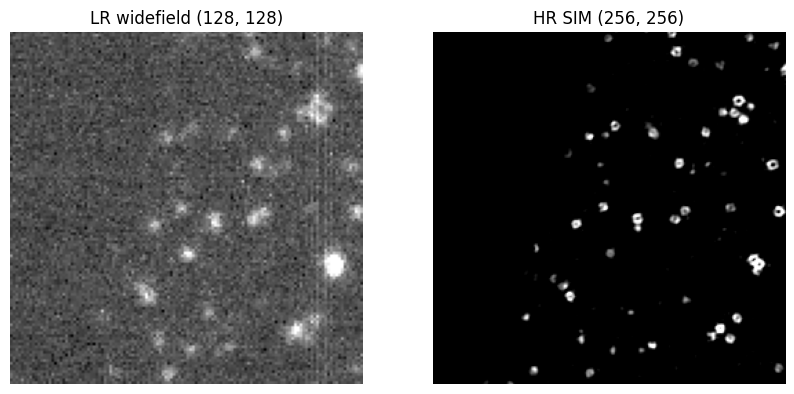

In [13]:
def build_model(a):
    return SRVAE(a.scale, a.lr_patch, a.z_dim, a.nf, a.fc_hidden)

root = os.path.join(cfg.data_root, cfg.structure)
train_pairs = load_folder_pairs(os.path.join(root, "training_wf"), os.path.join(root, "training_gt"), cfg.scale)
val_pairs   = load_folder_pairs(os.path.join(root, "validate_wf"), os.path.join(root, "validate_gt"), cfg.scale)
print(f"{len(train_pairs)} train / {len(val_pairs)} val images")

# quick look at one pair
lr0, hr0 = train_pairs[0]
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(lr0, cmap="gray"); ax[0].set_title(f"LR widefield {lr0.shape}")
ax[1].imshow(hr0, cmap="gray"); ax[1].set_title(f"HR SIM {hr0.shape}")
for x in ax: x.axis("off")
plt.show()

In [14]:
## for colab only
   #from google.colab import drive
   #drive.mount('/content/drive')

## 8. Train

In [ ]:
# ============================================================================================
# REPLACEMENT for the "8. Train" code cell (the one starting with os.makedirs(cfg.out_dir ...)).
# Iterations per epoch are now computed from the data size (pairs // batch).
# Adds: full checkpoints every SAVE_EVERY epochs (model + optimizer + LR scheduler + history),
# atomic writes (safe if Colab dies mid-save), and automatic resume after a disconnect.
# ============================================================================================
os.makedirs(cfg.out_dir, exist_ok=True)
model = build_model(cfg).to(dev)
print(f"parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.2f} M")

vgg = VGGFeat().to(dev) if cfg.vgg_weight > 0 else None
opt = torch.optim.Adam(model.parameters(), lr=cfg.lr, betas=(0.9, 0.999), weight_decay=cfg.weight_decay)
sched = torch.optim.lr_scheduler.MultiStepLR(opt, [cfg.epochs // 2], 0.1)   # paper: lr /10 after half
# one epoch = as many random crops as there are training pairs  ->  iterations = pairs // batch
## iteration based on datapoint and batch size
cfg.iters_per_epoch = max(1, len(train_pairs) // cfg.batch)
print(f"batch {cfg.batch} | {cfg.iters_per_epoch} iterations per epoch ({len(train_pairs)} training pairs)")
dl = DataLoader(PatchDataset(train_pairs, cfg.lr_patch, cfg.scale, cfg.iters_per_epoch * cfg.batch),
                batch_size=cfg.batch, num_workers=cfg.workers, drop_last=True,
                pin_memory=dev.type == "cuda")

SAVE_EVERY = 5      # full resumable checkpoint every N epochs (and at the last epoch)
RESUME = True       # True: continue from last.pt if it exists. False: start from scratch.

history, best, start_ep = [], -1.0, 1
last_path = os.path.join(cfg.out_dir, "last.pt")
best_path = os.path.join(cfg.out_dir, "best.pt")


def atomic_save(obj, path):
    """Write to a temp file, then rename, so a crash never leaves a half-written checkpoint."""
    tmp = path + ".tmp"
    torch.save(obj, tmp)
    os.replace(tmp, path)


# ---- resume ------------------------------------------------------------------------------
if RESUME and os.path.isfile(last_path):
    ck = torch.load(last_path, map_location=dev, weights_only=False)
    model.load_state_dict(ck["model"])
    opt.load_state_dict(ck["opt"])
    sched.load_state_dict(ck["sched"])
    history, best, start_ep = ck["history"], ck["best"], ck["epoch"] + 1
    print(f"resumed from epoch {ck['epoch']} (best val PSNR so far {best:.2f})")
    del ck

# ---- training loop -----------------------------------------------------------------------
for ep in range(start_ep, cfg.epochs + 1):
    model.train()
    t0, agg = time.time(), np.zeros(4)
    for lr_b, hr_b in dl:
        lr_b, hr_b = lr_b.to(dev), hr_b.to(dev)
        sr, mu, logvar = model(lr_b, hr_b)
        loss, l1, lv, kl = total_loss(sr, hr_b, mu, logvar, vgg, cfg.vgg_weight, cfg.kl_weight)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        agg += np.array([loss.item(), l1.item(), lv.item(), kl.item()])
    sched.step()
    agg /= len(dl)
    m = evaluate(model, val_pairs, dev, cfg.tile, cfg.overlap, cfg.val_images)
    history.append({"epoch": ep, "loss": float(agg[0]), "l1": float(agg[1]), "kl": float(agg[3]),
                    **{k: float(v) for k, v in m.items()}})
    print(f"ep {ep:03d} | loss {agg[0]:.4f} L1 {agg[1]:.4f} VGG {agg[2]:.4f} KL {agg[3]:.3f} | "
          f"val PSNR {m['psnr']:.2f} (bicubic {m['bic_psnr']:.2f}) SSIM {m['ssim']:.3f} "
          f"(bicubic {m['bic_ssim']:.3f}) | {time.time() - t0:.0f}s")

    # best model: weights only (small, fast to write) - this is what the evaluation cell loads
    if m["psnr"] > best:
        best = m["psnr"]
        atomic_save({"model": model.state_dict(), "args": vars(cfg), "epoch": ep, "metrics": m}, best_path)

    # full resumable state every SAVE_EVERY epochs and at the end
    if ep % SAVE_EVERY == 0 or ep == cfg.epochs:
        atomic_save({"model": model.state_dict(), "opt": opt.state_dict(), "sched": sched.state_dict(),
                     "args": vars(cfg), "epoch": ep, "metrics": m, "history": history, "best": best},
                    last_path)
        print(f"   checkpoint saved -> {last_path}")

parameters: 26.34 M
resumed from epoch 70 (best val PSNR so far 24.30)


KeyboardInterrupt: 

## 9. Training curves

In [ ]:
ep = [h["epoch"] for h in history]
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(ep, [h["loss"] for h in history], label="total"); ax[0].plot(ep, [h["l1"] for h in history], label="L1")
ax[0].set_title("train loss"); ax[0].legend()
ax[1].plot(ep, [h["psnr"] for h in history], label="SR-VAE"); ax[1].plot(ep, [h["bic_psnr"] for h in history], "--", label="bicubic")
ax[1].set_title("val PSNR (dB)"); ax[1].legend()
ax[2].plot(ep, [h["ssim"] for h in history], label="SR-VAE"); ax[2].plot(ep, [h["bic_ssim"] for h in history], "--", label="bicubic")
ax[2].set_title("val SSIM"); ax[2].legend()
plt.tight_layout(); plt.show()

## 10. Evaluate best checkpoint and visualise

In [ ]:
ck = torch.load(os.path.join(cfg.out_dir, "best.pt"), map_location=dev)
model = build_model(cfg).to(dev)
model.load_state_dict(ck["model"]); model.eval()
print(evaluate(model, val_pairs, dev, cfg.tile, cfg.overlap))

lr, hr = val_pairs[0]
lr_t = torch.from_numpy(lr)[None, None].to(dev)
sr = sr_full(model, lr_t, cfg.tile, cfg.overlap)[0, 0].cpu().numpy()
bic = F.interpolate(lr_t, scale_factor=cfg.scale, mode="bicubic", align_corners=False).clamp(0, 1)[0, 0].cpu().numpy()

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
for a_, im, t in zip(ax, [lr, bic, sr, hr],
                     ["LR widefield", "Bicubic", f"SR-VAE ({psnr(sr, hr):.2f} dB)", "HR SIM (GT)"]):
    a_.imshow(im, cmap="gray"); a_.set_title(t); a_.axis("off")
plt.tight_layout(); plt.show()

## 11. Inference on your own widefield image

In [ ]:
def infer_file(path, out_path="sr.tif"):
    import tifffile
    x = read_stack(path)
    while x.ndim > 2:
        x = x.mean(axis=0)
    x_t = torch.from_numpy(percentile_norm(x))[None, None].to(dev)
    out = sr_full(model, x_t, cfg.tile, cfg.overlap)[0, 0].cpu().numpy()
    tifffile.imwrite(out_path, out)
    return out

# sr_img = infer_file("my_widefield.tif", "my_sr.tif")